# **Evaluación 1 - Machine Learning**

# **Sección 1**

Genere las siguientes imágenes de manera sintética. \

NOTA: NO USE FUNCIONES ESPECIALES DE LIBRERÍAS DE PROCESAMIENTO DE IMÁGENES (CV, PIL, SKIMAGE) MÁS QUE PARA CARGARLAS O GUARDARLAS. USE SÓLO NUMPY Y OPERACIONES CON ARREGLOS

In [2]:
# Import some libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
import imageio
from google.colab.patches import cv2_imshow

# **Ejercicio 1 (C = 0.7)**

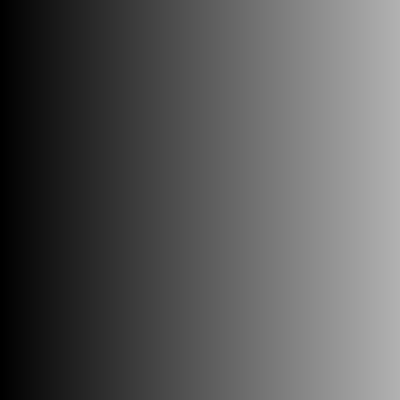

(400, 400)


In [3]:
# parámetro del ejercicio
C = 0.7

# tamaño de la imagen
alto = 400
ancho = 400

# crear imagen vacía
img = np.zeros((alto, ancho), dtype=np.uint8)

# crear degradado
for i in range(alto):
    for j in range(ancho):
        img[i, j] = int(C * (j / ancho) * 255)

# mostrar imagen
cv2_imshow(img)

print(img.shape)

# **Ejercicio 2 (C = 1.0)**

Ejercicio demostrando la imagen con poca resolución

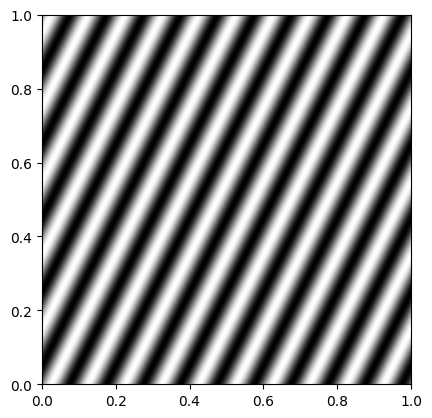

In [59]:
C = 1.0
n = 500

# coordenadas
x = np.linspace(0, C, n)
y = np.linspace(0, C, n)

X, Y = np.meshgrid(x, y)

# frecuencia
k = 20 * np.pi

# ajustar ángulo de las líneas
Z = np.sin(k * (X + 0.5*Y))

plt.imshow(Z, cmap='gray', extent=[0, C, 0, C])
plt.show()

Ejercicio demostrando la imagen con mucha resolución

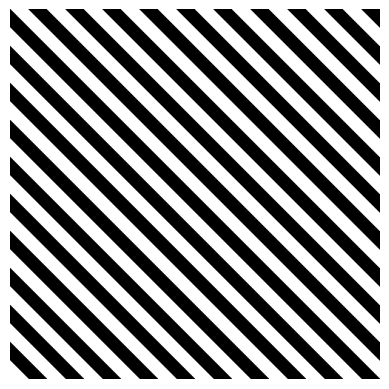

In [39]:
C = 1.0
n = 500   # resolución alta como pide el ejercicio

# Crear coordenadas
x = np.linspace(0, C, n)
y = np.linspace(0, C, n)

X, Y = np.meshgrid(x, y)

# Frecuencia de las líneas
k = 20 * np.pi

# Generar patrón diagonal
Z = np.sin(k * (X - Y))

# Convertir a blanco y negro
Z = Z > 0

# Mostrar imagen
plt.imshow(Z, cmap='gray', extent=[0, C, 0, C])
plt.axis('off')
plt.show()

# **Sección 2**
Genere las siguientes imágenes usando recorridos por píxeles a partir de lena.jpg y bengal_tiger.jpg

NOTA: NO USE FUNCIONES ESPECIALES DE LIBRERÍAS DE PROCESAMIENTO DE IMÁGENES (CV, PIL, SKIMAGE) MÁS QUE PARA CARGARLAS O GUARDARLAS. USE SÓLO NUMPY Y OPERACIONES CON ARREGLOS

# **Ejercicio 3 (C = 1.6)**

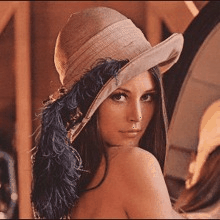

In [ ]:
# Parámetro del ejercicio
C = 1.6

# Cargar las imágenes
img1 = cv2.imread("Lenna.png")
img2 = cv2.imread("Tigre.png")

# Redimensionar img2 si es necesario
img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

# Número de pasos de la transición
steps = 50

# Lista para almacenar los frames
frames = []

for i in range(steps + 1):
    alpha = i / steps
    beta = 1 - alpha

    # Mezcla con el parámetro C
    blended = (img1 * beta + img2 * alpha + C).astype(np.uint8)

    # Convertir a RGB para imageio
    blended_rgb = cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)
    frames.append(blended_rgb)

# Guardar como GIF
imageio.mimsave('transicion.gif', frames, duration=0.05)

# Mostrar el GIF
from IPython.display import Image
Image(filename='transicion.gif')

# **Ejercicio 4 (C = 1.0)**

Uso este comando para poner la imagen en escala 2 porque al cargarla normal la imagen queda muy pequeña

img = np.repeat(np.repeat(img, 2, axis=0), 2, axis=1)


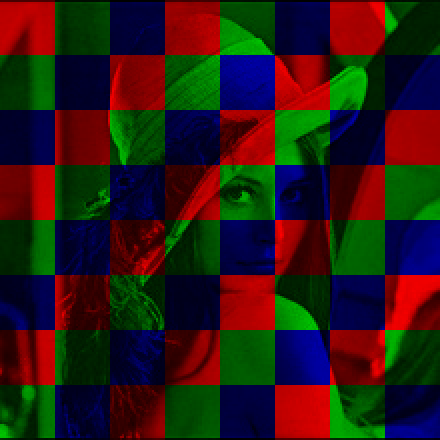

In [62]:
# parámetro del ejercicio
C = 1.0

# cargar imagen
img = cv2.imread("Lenna.png")

# hacer la imagen más grande solo con NumPy (2x)
img = np.repeat(np.repeat(img, 2, axis=0), 2, axis=1)

alto, ancho, canales = img.shape

bloque = 55

resultado = np.zeros_like(img)

for i in range(alto):
    for j in range(ancho):

        bi = i // bloque
        bj = j // bloque

        if (bi + bj) % 3 == 0:
            resultado[i,j,2] = int(C * img[i,j,2])  # rojo

        elif (bi + bj) % 3 == 1:
            resultado[i,j,1] = int(C * img[i,j,1])  # verde

        else:
            resultado[i,j,0] = int(C * img[i,j,0])  # azul

cv2_imshow(resultado)

# **Ejercicio 5 (C = 0.7)**

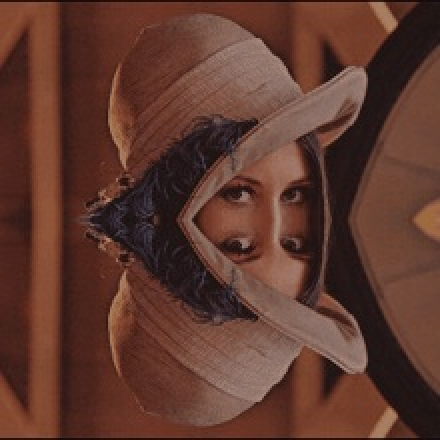

In [ ]:
# parámetro del ejercicio
C = 0.7

# cargar imagen
img = cv2.imread("Lenna.png")

# hacer la imagen más grande solo con NumPy (2x)
img = np.repeat(np.repeat(img, 2, axis=0), 2, axis=1)


alto, ancho, canales = img.shape

# crear imagen resultado
resultado = np.zeros_like(img)

for i in range(alto):
    for j in range(ancho):

        if i < alto//2:
            resultado[i,j] = C * img[i,j]

        else:
            resultado[i,j] = C * img[alto-i-1, j]

cv2_imshow(resultado.astype(np.uint8))